# Análise de Churn - Plataforma de Streaming

## Objetivo do Projeto

O objetivo desta análise é identificar possíveis padrões e fatores relacionados ao cancelamento de assinaturas (*churn*) em uma plataforma de streaming.

Durante o projeto serão realizadas etapas de:
- compreensão dos dados;
- limpeza e tratamento;
- tradução e padronização das informações;
- análise exploratória;
- visualização de dados;
- interpretação dos principais insights encontrados.

---

# Importação das Bibliotecas

As bibliotecas utilizadas neste projeto serão responsáveis pela manipulação, tratamento e visualização dos dados.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---

# Leitura do Dataset

Nesta etapa será realizado o carregamento do dataset e uma análise inicial da estrutura dos dados.

In [2]:
df = pd.read_csv('./data/netflix_customer_churn.csv')

pd.options.display.float_format = '{:.2f}'.format

---

# Entendimento Inicial dos Dados

Aqui serão verificadas informações importantes do dataset, como:
- quantidade de linhas e colunas;
- tipos de dados;
- valores nulos;
- estatísticas descritivas;
- possíveis inconsistências.

In [3]:
df.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [4]:
print(f"O dataset possui {df.shape[0]} linhas e {df.shape[1]} colunas.")

O dataset possui 5000 linhas e 14 colunas.


In [5]:
df.columns

Index(['customer_id', 'age', 'gender', 'subscription_type', 'watch_hours',
       'last_login_days', 'region', 'device', 'monthly_fee', 'churned',
       'payment_method', 'number_of_profiles', 'avg_watch_time_per_day',
       'favorite_genre'],
      dtype='object')

# Descrição das Colunas

| Coluna | Descrição |
|---|---|
| `customer_id` | Identificador único de cada cliente da plataforma. |
| `age` | Idade do cliente. |
| `gender` | Gênero do cliente. |
| `subscription_type` | Tipo de assinatura contratada pelo usuário. |
| `watch_hours` | Quantidade total de horas assistidas pelo usuário na plataforma. |
| `last_login_days` | Quantidade de dias desde o último acesso do usuário. |
| `region` | Região onde o usuário está localizado. |
| `device` | Dispositivo mais utilizado para acessar a plataforma. |
| `monthly_fee` | Valor mensal pago pela assinatura. |
| `churned` | Indica se o cliente cancelou ou não a assinatura. |
| `payment_method` | Método de pagamento utilizado pelo cliente. |
| `number_of_profiles` | Quantidade de perfis existentes na conta. |
| `avg_watch_time_per_day` | Percentual médio diário de tempo consumido na plataforma. |
| `favorite_genre` | Gênero de conteúdo mais assistido pelo usuário. |

## Separação das Colunas Numéricas e Categóricas

Para facilitar a análise exploratória dos dados, as colunas do dataset foram separadas entre variáveis numéricas e categóricas.

Essa divisão permite aplicar métodos e visualizações mais adequados para cada tipo de dado, tornando a análise mais organizada e eficiente.

- Variáveis numéricas serão utilizadas principalmente para análises estatísticas e distribuição dos dados.
- Variáveis categóricas serão utilizadas para análises de frequência, comparação entre categorias e relação com o churn.

In [6]:
colunas_numericas = [
    "age",
    "watch_hours",
    "last_login_days",
    "monthly_fee",
    "number_of_profiles",
    "avg_watch_time_per_day"
]

colunas_categoricas = [
    "gender",
    "subscription_type",
    "region",
    "device",
    "payment_method",
    "favorite_genre",
    "churned"
]

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   object 
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   object 
dtypes: float64(3), int64(4), object(7)
memor

In [8]:
df.describe()

,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,43.85,11.65,30.09,13.68,0.50,3.02,0.87
std,15.50,12.01,17.54,3.69,0.50,1.42,2.62
min,18.00,0.01,0.00,8.99,0.00,1.00,0.00
25%,30.00,3.34,15.00,8.99,0.00,2.00,0.11
50%,44.00,8.00,30.00,13.99,1.00,3.00,0.29
75%,58.00,16.03,45.00,17.99,1.00,4.00,0.72
max,70.00,110.40,60.00,17.99,1.00,5.00,98.42


In [9]:
df.isnull().sum()

customer_id               0
age                       0
gender                    0
subscription_type         0
watch_hours               0
last_login_days           0
region                    0
device                    0
monthly_fee               0
churned                   0
payment_method            0
number_of_profiles        0
avg_watch_time_per_day    0
favorite_genre            0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
for coluna in colunas_categoricas:
    print(f"\n📌", end=" ")
    print(df[coluna].value_counts())


📌 gender
Female    1711
Male      1654
Other     1635
Name: count, dtype: int64

📌 subscription_type
Premium     1693
Basic       1661
Standard    1646
Name: count, dtype: int64

📌 region
South America    873
Europe           867
North America    851
Asia             841
Africa           803
Oceania          765
Name: count, dtype: int64

📌 device
Tablet     1048
Laptop     1006
Mobile     1004
TV          993
Desktop     949
Name: count, dtype: int64

📌 payment_method
Debit Card     1030
PayPal         1026
Crypto          995
Gift Card       976
Credit Card     973
Name: count, dtype: int64

📌 favorite_genre
Drama          731
Documentary    729
Romance        725
Sci-Fi         720
Horror         713
Action         697
Comedy         685
Name: count, dtype: int64

📌 churned
1    2515
0    2485
Name: count, dtype: int64


---

# Limpeza e Tratamento dos Dados

Após a análise inicial do dataset, foi possível observar que não existem valores ausentes, registros duplicados e nem valores despadronizados relevantes que necessitem tratamento.

Dessa forma, esta etapa será focada em:
- análise de possíveis outliers;
- tradução das colunas e categorias;
- organização dos dados para facilitar a análise exploratória.

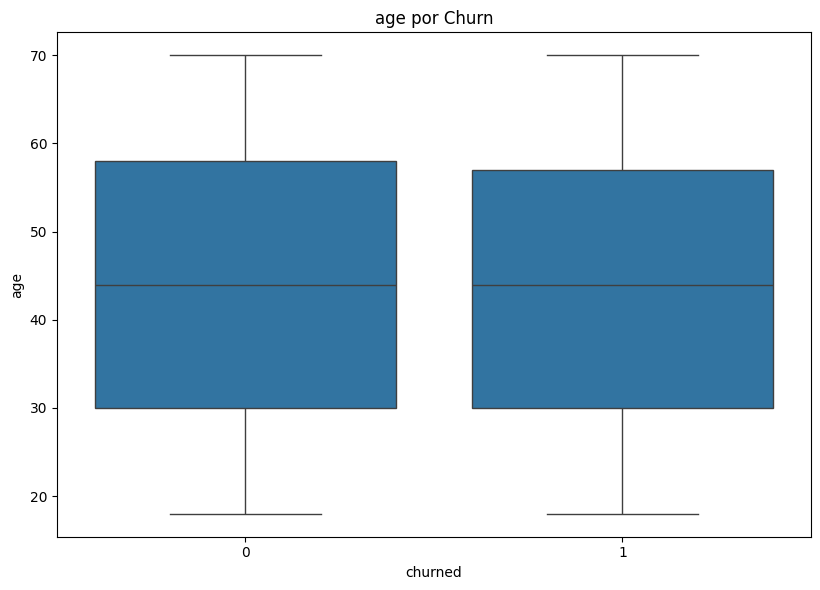

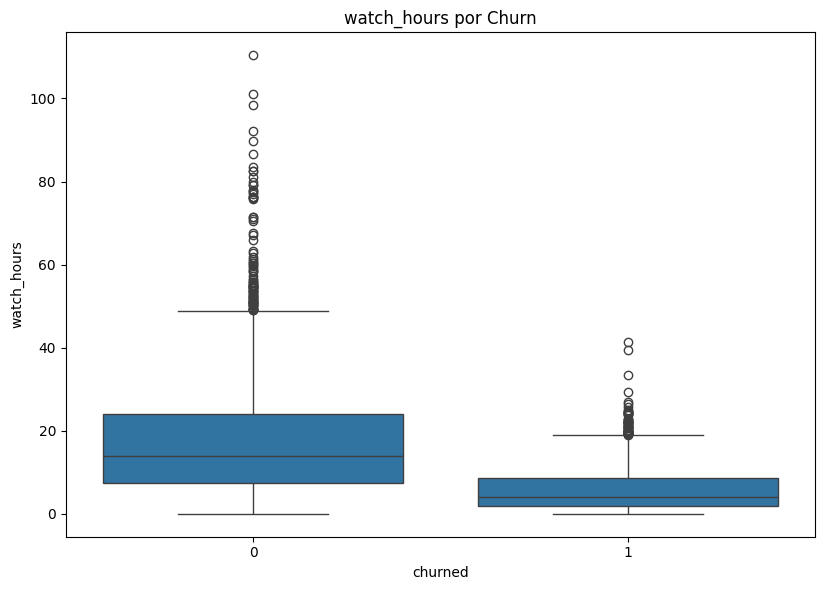

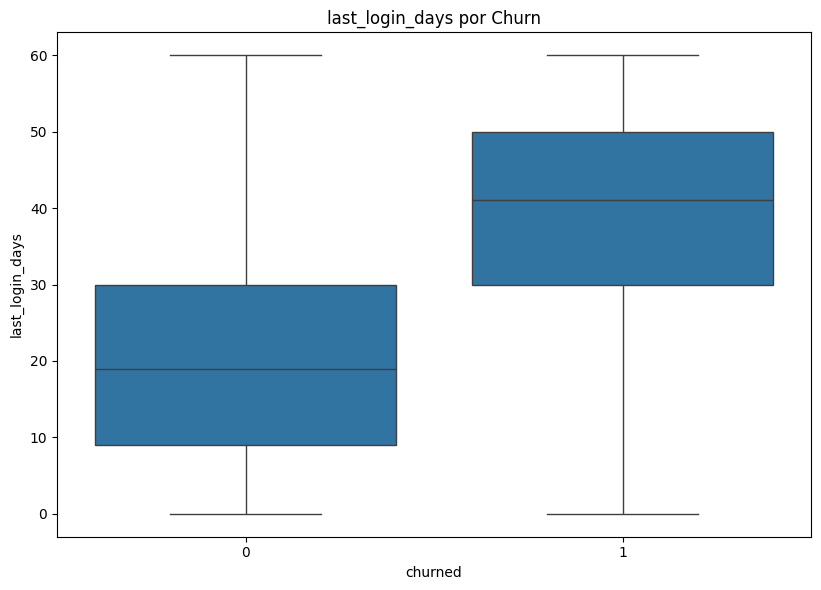

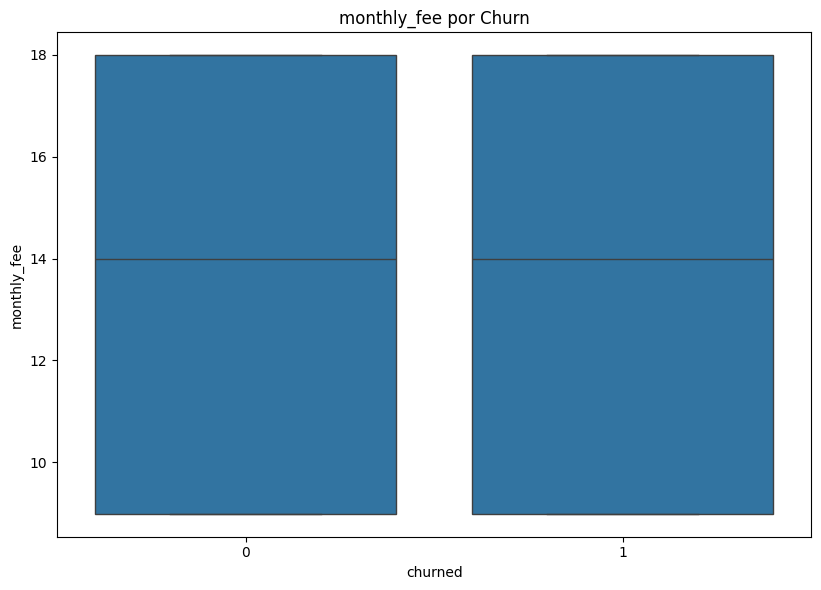

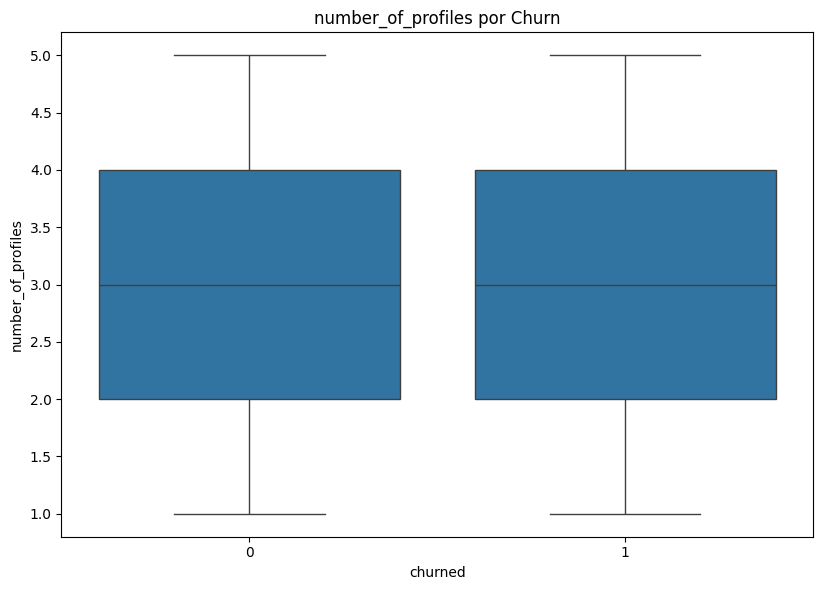

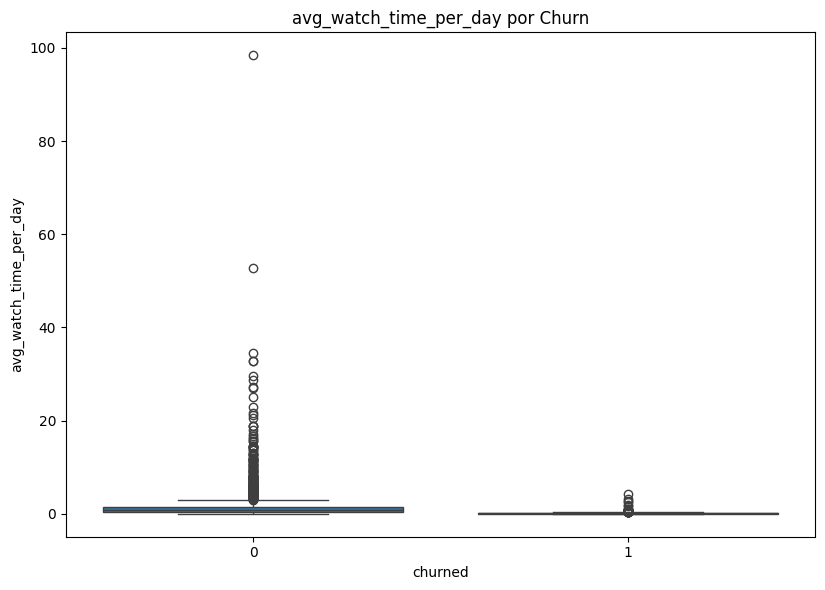

In [12]:
for coluna in colunas_numericas:
    
    plt.figure(figsize=(16,6))
    
    # Gráfico com churn
    plt.subplot(1, 2, 2)
    
    sns.boxplot(
        data=df,
        x="churned",
        y=coluna
    )
    
    plt.title(f"{coluna} por Churn")
    
    
    plt.tight_layout()
    plt.show()

### Análise dos Outliers

Durante a análise dos boxplots, foram identificados alguns valores considerados outliers em determinadas variáveis numéricas.

Entretanto, optou-se por não realizar a remoção desses valores, pois eles podem representar comportamentos reais dos usuários da plataforma.

No contexto de serviços de streaming, contas podem possuir múltiplos perfis ativos simultaneamente, o que pode gerar valores elevados de consumo diário. Além disso, existem usuários com padrões de uso intensivo, assistindo conteúdos por várias horas ao longo do dia.

Dessa forma, a remoção desses dados poderia eliminar informações relevantes sobre o comportamento real dos clientes e impactar negativamente a análise do churn.



## Tradução e Padronização dos Dados

Com o objetivo de facilitar a interpretação e visualização das informações, foi realizada a tradução dos nomes das colunas e de algumas categorias do dataset para português.

Além da tradução, também foi realizada a padronização de valores categóricos e monetários, tornando os dados mais organizados e compreensíveis durante a análise exploratória.

Essas alterações contribuem para uma leitura mais clara dos gráficos, tabelas e insights obtidos ao longo do projeto.

In [13]:
tradução_colunas = {
    "customer_id": "id_cliente",
    "age": "idade",
    "gender": "genero",
    "subscription_type": "tipo_assinatura",
    "watch_hours": "horas_assistidas",
    "last_login_days": "ultimo_dia_logado",
    "region": "regiao",
    "device": "dispositivo",
    "monthly_fee": "pagamento_mensal",
    "churned": "churn",
    "payment_method": "metodo_pagamento",
    "number_of_profiles": "quantidade_perfis",
    "avg_watch_time_per_day": "porcentagem_assistida_por_dia",
    "favorite_genre": "genero_favorito"
}

df.rename(columns=tradução_colunas, inplace=True)

df["tipo_assinatura"] = df["tipo_assinatura"].map({
    "Basic": "Padrão com anúncios",
    "Standard": "Padrão",
    "Premium": "Premium"
})

df["metodo_pagamento"] = df["metodo_pagamento"].map({
    "Credit Card": "Cartão de Crédito",
    "Debit Card": "Cartão de Débito",
    "Crypto": "Criptomoeda",
    "PayPal": "PayPal",
    "Gift Card": "Cartão Presente"
})

df["genero"] = df["genero"].map({
    "Male": "Masculino",
    "Female": "Feminino",
    "Other": "Outro"
})

df["pagamento_mensal"] = df["pagamento_mensal"].map({
    8.99: 20.90,
    13.99: 44.90,
    17.99: 59.90
})

df["genero_favorito"] = df["genero_favorito"].map({
    "Documentary": "Documentário",
    "Action": "Ação",
    "Comedy": "Comédia",
    "Horror": "Terror",
    "Romance": "Romance",
    "Sci-Fi": "Ficção Científica",
    "Drama": "Drama",
})

df["regiao"] = df["regiao"].map({
    "North America": "América do Norte",
    "Europe": "Europa",
    "Asia": "Ásia",
    "South America": "América do Sul",
    "Africa": "África",
    "Oceania": "Oceania"
})

df["dispositivo"] = df["dispositivo"].map({
    "Mobile": "Celular",
    "Tablet": "Tablet",
    "Desktop": "Computador",
    "TV": "TV",
    "Laptop": "Notebook"
})

In [14]:
df.head()

,id_cliente,idade,genero,tipo_assinatura,horas_assistidas,ultimo_dia_logado,regiao,dispositivo,pagamento_mensal,churn,metodo_pagamento,quantidade_perfis,porcentagem_assistida_por_dia,genero_favorito
0,a9b75100-82a8-427a-a208-72f24052884a,51,Outro,Padrão com anúncios,14.73,29,África,TV,20.90,1,Cartão Presente,1,0.49,Ação
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Outro,Padrão,0.70,19,Europa,Celular,44.90,1,Cartão Presente,5,0.03,Ficção Científica
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Feminino,Padrão,16.32,10,Ásia,TV,44.90,0,Criptomoeda,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Outro,Premium,4.51,12,Oceania,TV,59.90,1,Criptomoeda,2,0.35,Terror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Outro,Padrão,1.89,13,África,Celular,44.90,1,Criptomoeda,2,0.13,Ação


In [15]:
df.columns

Index(['id_cliente', 'idade', 'genero', 'tipo_assinatura', 'horas_assistidas',
       'ultimo_dia_logado', 'regiao', 'dispositivo', 'pagamento_mensal',
       'churn', 'metodo_pagamento', 'quantidade_perfis',
       'porcentagem_assistida_por_dia', 'genero_favorito'],
      dtype='object')

# Descrição das Colunas

| Coluna | Descrição |
|---|---|
| `id_cliente` | Identificador único de cada cliente da plataforma. |
| `idade` | Idade do cliente. |
| `genero` | Gênero do cliente. |
| `tipo_assinatura` | Tipo de assinatura contratada pelo usuário. |
| `horas_assistidas` | Quantidade total de horas assistidas pelo usuário na plataforma. |
| `ultimo_dia_logado` | Quantidade de dias desde o último acesso do usuário na plataforma. |
| `regiao` | Região onde o usuário está localizado. |
| `dispositivo` | Dispositivo mais utilizado para acessar a plataforma. |
| `pagamento_mensal` | Valor mensal pago pela assinatura. |
| `churn` | Indica se o cliente cancelou ou manteve a assinatura. |
| `metodo_pagamento` | Método de pagamento utilizado pelo cliente. |
| `quantidade_perfis` | Quantidade de perfis existentes na conta. |
| `porcentagem_assistida_por_dia` | Percentual médio diário de consumo da plataforma pela conta. |
| `genero_favorito` | Gênero de conteúdo mais assistido pelo usuário. |

In [ ]:
#  Salvando o dataset traduzido e tratado para facilitar a análise exploratória e visualização dos dados.
#  df.to_csv('./data/netflix_clientes_churn_traduzido.csv', index=False)

---

# Análise Exploratória dos Dados

Após as etapas de limpeza, tratamento e padronização dos dados, inicia-se a Análise Exploratória dos Dados (EDA).

O objetivo desta etapa é identificar padrões, comportamentos e possíveis fatores relacionados ao churn dos clientes da plataforma.

Serão realizadas análises utilizando variáveis numéricas e categóricas, buscando compreender como diferentes características dos usuários podem influenciar o cancelamento da assinatura.

Além disso, serão utilizados gráficos e estatísticas descritivas para facilitar a interpretação dos dados e apoiar a identificação dos principais insights do projeto.

In [17]:
df = pd.read_csv('./data/netflix_clientes_churn_traduzido.csv')

In [18]:
colunas_numericas = [
    "idade",
    "horas_assistidas",
    "ultimo_dia_logado",
    "pagamento_mensal",
    "quantidade_perfis",
    "porcentagem_assistida_por_dia"
]

colunas_categoricas = [
    "genero",
    "tipo_assinatura",
    "regiao",
    "dispositivo",
    "metodo_pagamento",
    "genero_favorito",
    "churn"
]

In [19]:
df["churn"].value_counts(normalize=True) * 100

churn
1   50.30
0   49.70
Name: proportion, dtype: float64

<Axes: xlabel='churn', ylabel='count'>

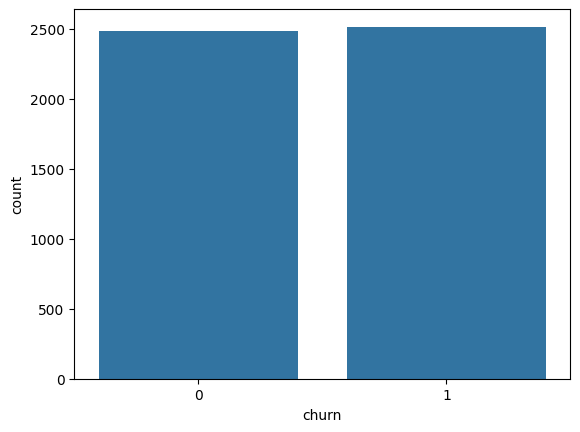

In [20]:
sns.countplot(data=df, x="churn")

## Análise Inicial do Churn

A análise inicial da variável `churn` mostrou uma taxa de cancelamento de aproximadamente 50,30%.

Esse valor indica um nível elevado de evasão de clientes, sugerindo possíveis problemas relacionados ao engajamento, retenção ou experiência dos usuários na plataforma.

Além disso, os boxplots das variáveis numéricas indicaram alguns padrões importantes relacionados ao cancelamento das assinaturas. Usuários com mais de 30 dias sem realizar login apresentaram maior tendência ao churn, assim como clientes com baixo percentual médio de consumo diário da plataforma.

Esses comportamentos sugerem que a falta de uso e o baixo engajamento podem estar fortemente associados ao cancelamento das assinaturas.

Dessa forma, torna-se importante investigar quais outros fatores podem estar relacionados ao churn dos clientes.

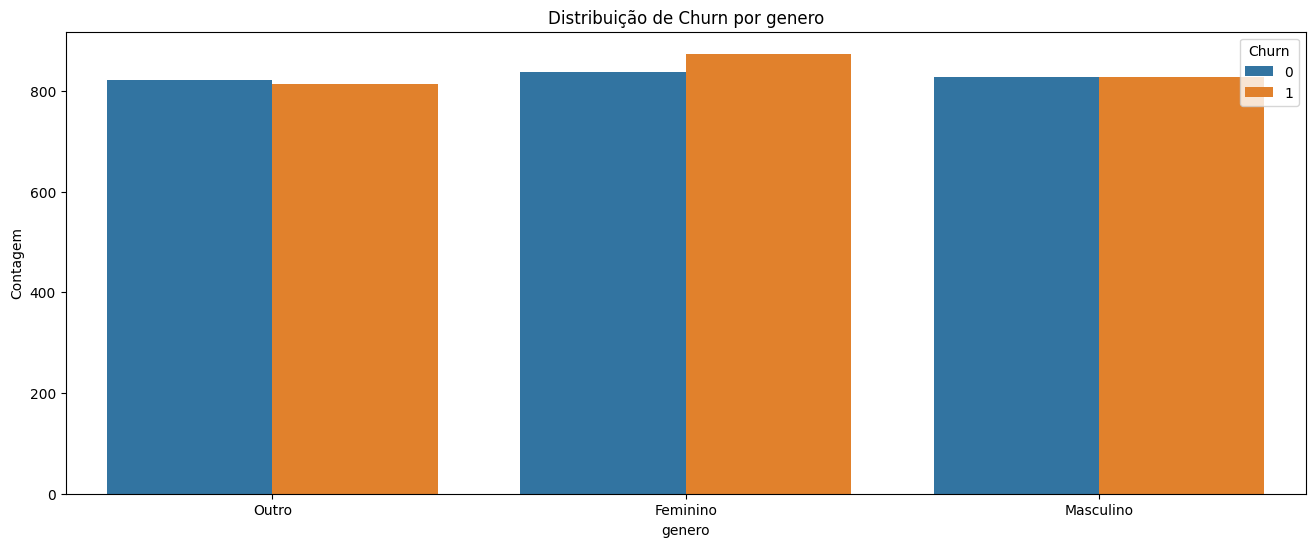

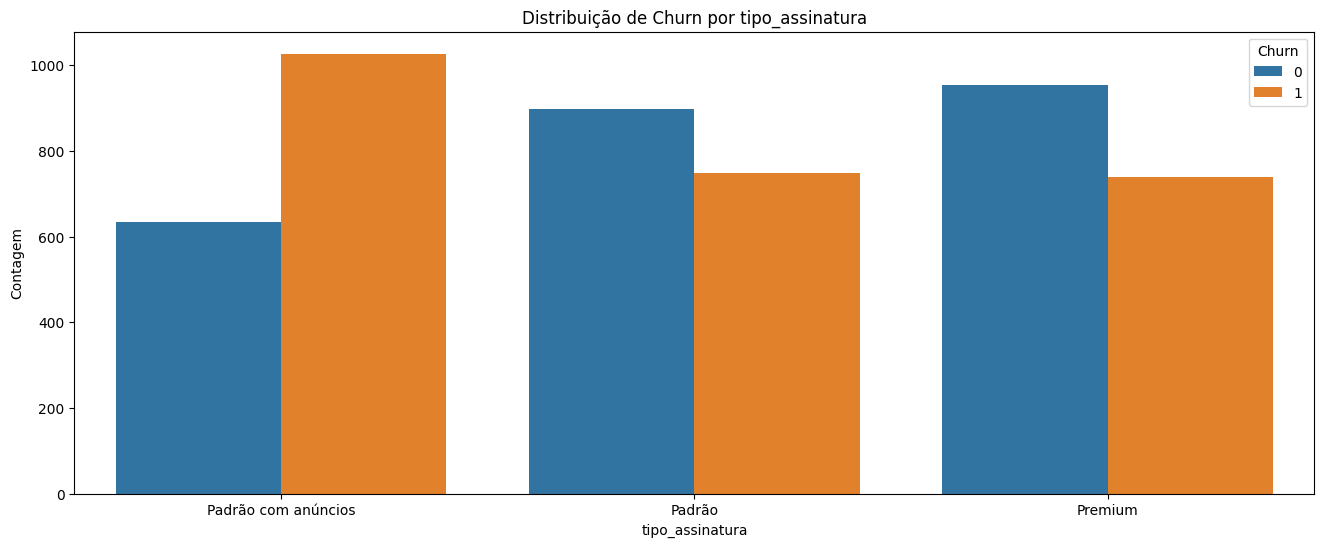

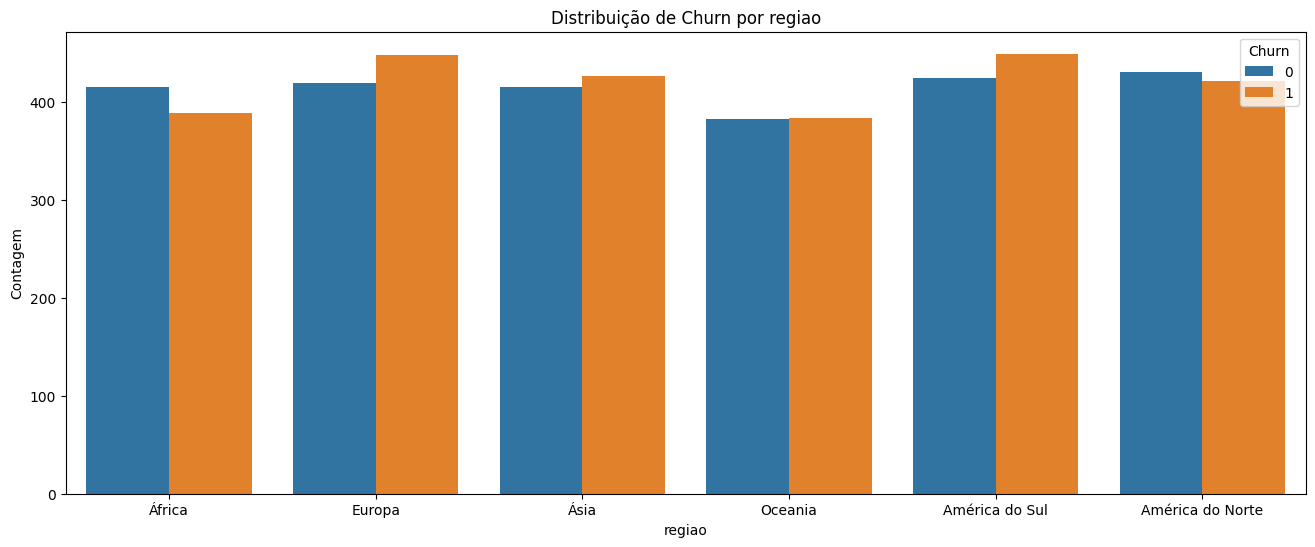

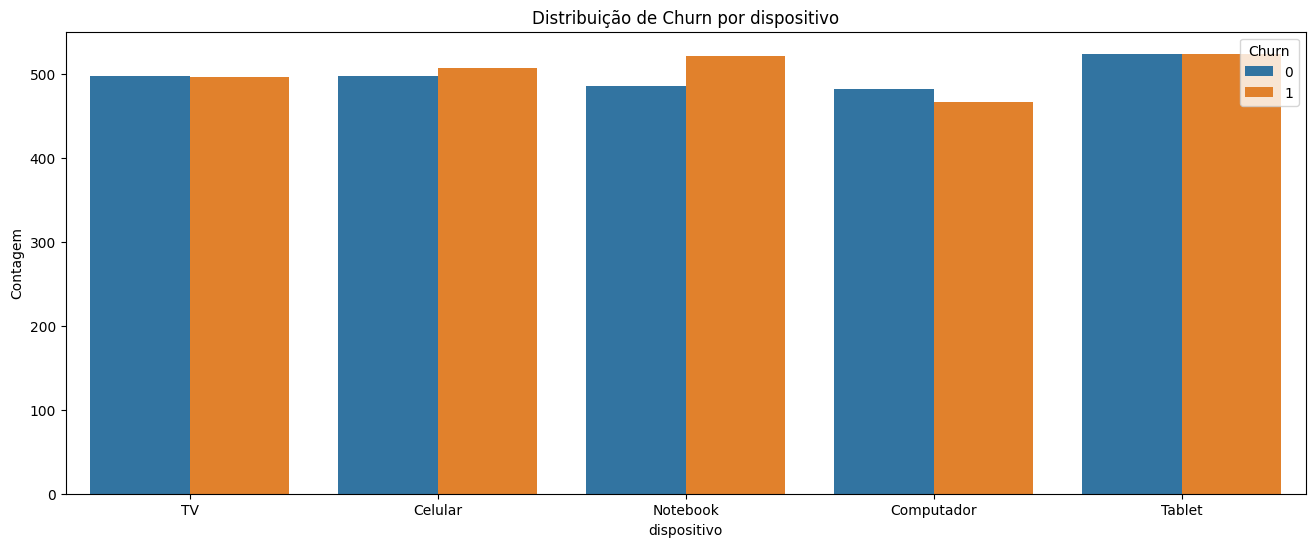

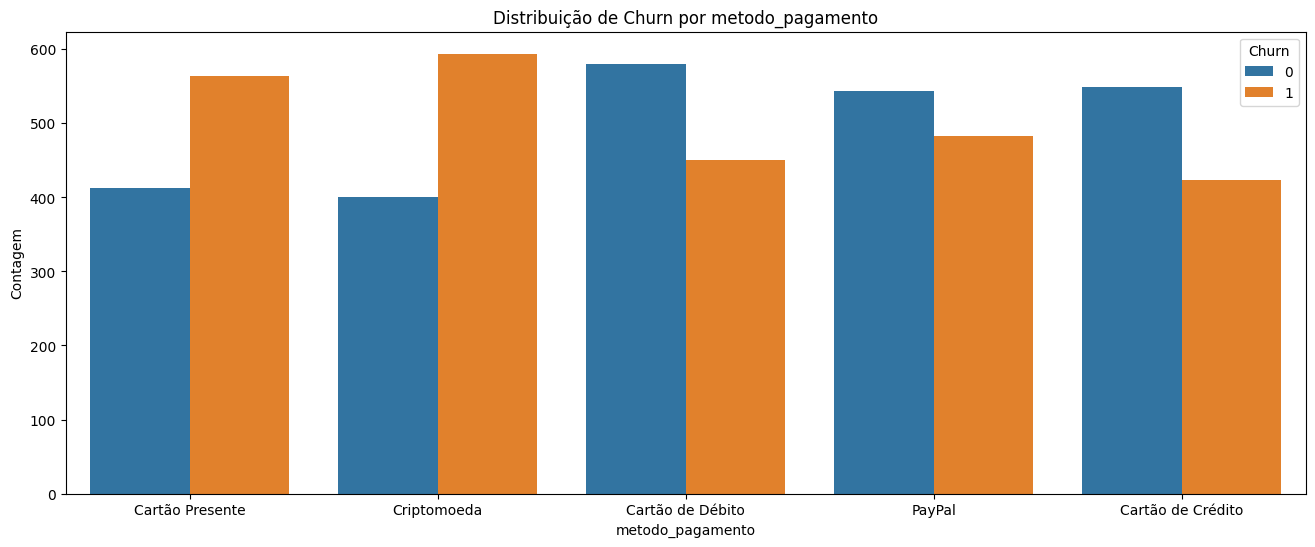

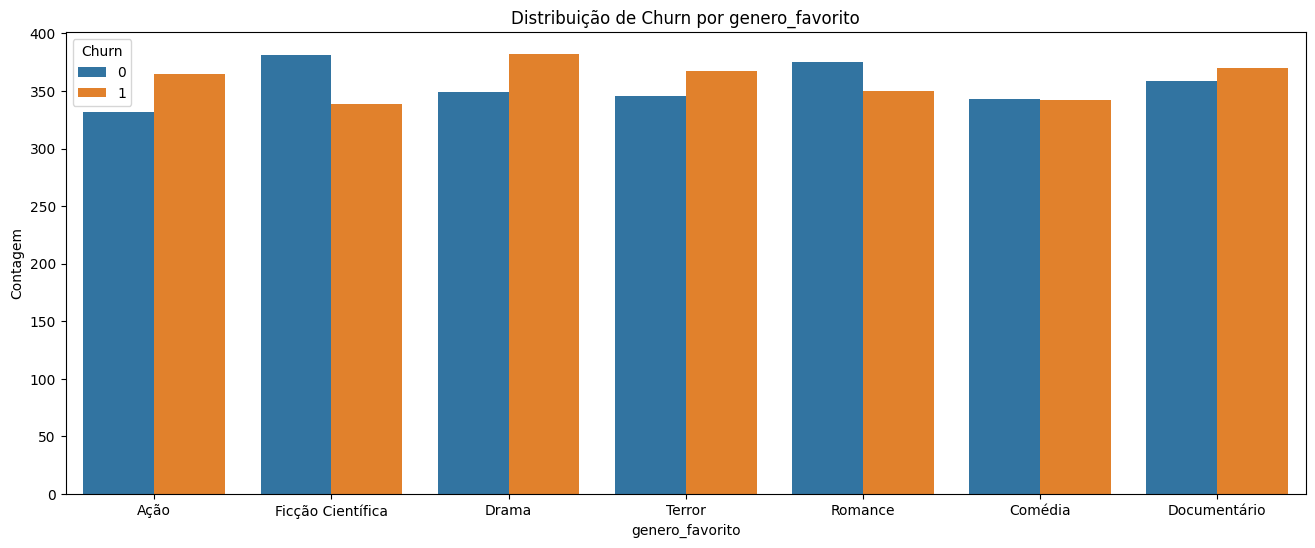

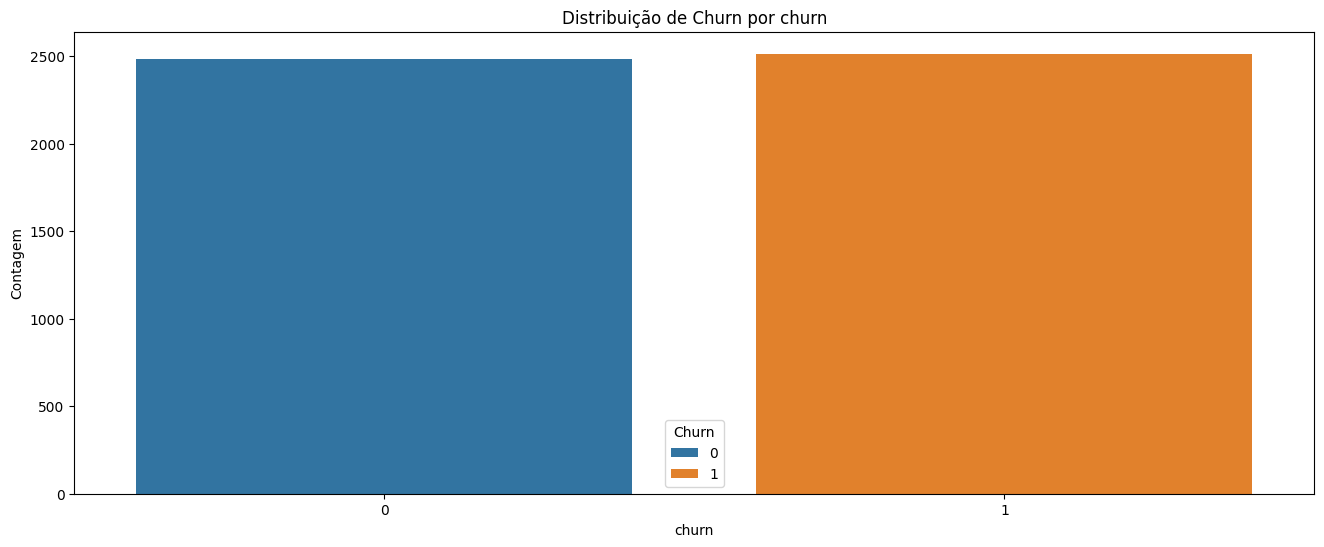

In [21]:
for coluna in colunas_categoricas:
    plt.figure(figsize=(16,6))
    sns.countplot(data=df, x=coluna, hue="churn")
    plt.title(f"Distribuição de Churn por {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Contagem")
    plt.legend(title="Churn")
    plt.show()